# 06c — EnbPI online para todos los modelos

Este notebook aplica **Ensemble Batch Prediction Intervals (EnbPI)** en una configuración **online simulada** sobre los cuatro modelos puntuales del proyecto:

- modelo base ingenuo estacional;
- regresión lineal;
- LightGBM;
- CatBoost.

La evaluación se realiza retrospectivamente sobre el bloque de validación, recorriendo las predicciones en orden temporal. Para evitar fuga temporal en horizontes mayores que una hora, la actualización online de los *conformal scores* solo utiliza observaciones cuyo `target_timestamp` ya estaría disponible en el `origin_timestamp` de la predicción actual.

> Nota metodológica: EnbPI no requiere un conjunto de calibración separado. Por defecto, este notebook entrena con `train + calibration` y evalúa en `validation`. El bloque `test` queda protegido.


## 1. Importaciones y configuración general

In [1]:
from __future__ import annotations

import inspect
import json
import warnings
from pathlib import Path
from typing import Dict, List

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

try:
    from mapie.regression import TimeSeriesRegressor
except ImportError:
    try:
        from mapie.regression import MapieTimeSeriesRegressor as TimeSeriesRegressor
    except ImportError as exc:
        raise ImportError(
            "No se ha podido importar TimeSeriesRegressor ni MapieTimeSeriesRegressor. "
            "Revisa la versión de MAPIE instalada."
        ) from exc

try:
    from mapie.subsample import BlockBootstrap
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere BlockBootstrap de MAPIE para aplicar EnbPI."
    ) from exc

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

warnings.filterwarnings("ignore")


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual."""
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook desde "
        "la raíz del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()

MODELING_DATA_DIR = PROJECT_ROOT / "data" / "modeling"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_INTERVALS_DIR = PROJECT_ROOT / "reports" / "intervals"
MODELS_ROOT_DIR = PROJECT_ROOT / "models"
ENBPI_MODELS_DIR = MODELS_ROOT_DIR / "enbpi_online"

for directory in [REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR, REPORTS_INTERVALS_DIR, ENBPI_MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS_PATH = MODELING_DATA_DIR / "feature_columns.json"

HORIZONS: List[int] = [1, 4, 12, 24]

# EnbPI no necesita un conjunto de calibración separado. Para predecir 2024,
# se aprovecha toda la información anterior disponible: train + calibration.
ENBPI_TRAIN_SPLITS: List[str] = ["train", "calibration"]
EVALUATION_SPLIT = "validation"
ALLOW_TEST_EVALUATION = False

ALPHA = 0.20
CONFIDENCE_LEVEL = 1 - ALPHA
NOMINAL_COVERAGE = CONFIDENCE_LEVEL

# Parámetros de EnbPI. Si el notebook resulta lento, reduce N_RESAMPLINGS a 5
# para una primera prueba rápida.
N_RESAMPLINGS = 10
N_BLOCKS = 10
OVERLAPPING_BLOCKS = False
RANDOM_STATE = 42
N_JOBS = -1
AGG_FUNCTION = "mean"
OPTIMIZE_BETA = False

# Muy importante para h > 1: no se actualizan scores con objetivos que aún no
# estarían observados en el instante de origen de la predicción actual.
RESPECT_TARGET_DELAY_IN_ONLINE_UPDATE = True

# Si alguna versión de MAPIE/estimador no acepta valores ausentes en X, activa esto.
FORCE_MEDIAN_IMPUTATION_FOR_MAPIE = False

SAVE_FITTED_MAPIE_OBJECTS = False
BASELINE_FEATURE = "o3_prev_day_same_hour"

if EVALUATION_SPLIT == "test" and not ALLOW_TEST_EVALUATION:
    raise ValueError(
        "Este notebook está configurado para no evaluar sobre test. "
        "Si realmente quieres hacerlo, cambia ALLOW_TEST_EVALUATION=True."
    )

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Datasets de modelado: {MODELING_DATA_DIR}")
print(f"Modelos puntuales: {MODELS_ROOT_DIR}")
print(f"Intervalos EnbPI: {REPORTS_INTERVALS_DIR}")
print(f"Train splits EnbPI: {ENBPI_TRAIN_SPLITS}")
print(f"Split de evaluación: {EVALUATION_SPLIT}")
print(f"Cobertura nominal: {NOMINAL_COVERAGE:.0%}")


Raíz del proyecto: c:\trabajo_github
Datasets de modelado: c:\trabajo_github\data\modeling
Modelos puntuales: c:\trabajo_github\models
Intervalos EnbPI: c:\trabajo_github\reports\intervals
Train splits EnbPI: ['train', 'calibration']
Split de evaluación: validation
Cobertura nominal: 80%


In [3]:
MODEL_REGISTRY: Dict[str, Dict[str, object]] = {
    "baseline_seasonal_naive": {
        "display_name": "Modelo base ingenuo estacional",
        "short_name": "Baseline",
        "label": "Baseline + EnbPI online",
        "color": "tab:blue",
        "model_dir": None,
        "model_file_pattern": None,
        "interval_prefix": "enbpi_online_baseline_seasonal_naive",
    },
    "linear_regression": {
        "display_name": "Regresión lineal",
        "short_name": "Reg. lineal",
        "label": "Regresión lineal + EnbPI online",
        "color": "tab:green",
        "model_dir": MODELS_ROOT_DIR / "linear_regression",
        "model_file_pattern": "linear_regression_h{horizon:02d}.joblib",
        "interval_prefix": "enbpi_online_linear_regression",
    },
    "lightgbm": {
        "display_name": "LightGBM",
        "short_name": "LightGBM",
        "label": "LightGBM + EnbPI online",
        "color": "tab:red",
        "model_dir": MODELS_ROOT_DIR / "lightgbm",
        "model_file_pattern": "lightgbm_h{horizon:02d}.joblib",
        "interval_prefix": "enbpi_online_lightgbm",
    },
    "catboost": {
        "display_name": "CatBoost",
        "short_name": "CatBoost",
        "label": "CatBoost + EnbPI online",
        "color": "tab:purple",
        "model_dir": MODELS_ROOT_DIR / "catboost",
        "model_file_pattern": "catboost_h{horizon:02d}.joblib",
        "interval_prefix": "enbpi_online_catboost",
    },
}

MODEL_ORDER = list(MODEL_REGISTRY.keys())
MODEL_ORDER


['baseline_seasonal_naive', 'linear_regression', 'lightgbm', 'catboost']

## 2. Carga de variables predictoras y datasets por horizonte

In [4]:
if not FEATURE_COLUMNS_PATH.exists():
    raise FileNotFoundError(
        "No se ha encontrado data/modeling/feature_columns.json. "
        "Ejecuta antes 02_modeling_dataset_features.ipynb."
    )

feature_payload = json.loads(FEATURE_COLUMNS_PATH.read_text(encoding="utf-8"))
feature_columns_by_horizon: Dict[str, List[str]] = feature_payload.get("feature_columns_by_horizon", {})
default_feature_columns: List[str] = feature_payload.get("feature_columns", [])

if not feature_columns_by_horizon and not default_feature_columns:
    raise ValueError("feature_columns.json no contiene variables predictoras.")

feature_summary_rows = []
for horizon in HORIZONS:
    cols = feature_columns_by_horizon.get(str(horizon), default_feature_columns)
    feature_summary_rows.append({"horizon": horizon, "n_features": len(cols), "features": cols})

feature_summary_df = pd.DataFrame(feature_summary_rows)
display(feature_summary_df[["horizon", "n_features"]])


,horizon,n_features
0,1,21
1,4,21
2,12,20
3,24,20


In [5]:
def load_modeling_dataset(horizon: int) -> pd.DataFrame:
    file_path = MODELING_DATA_DIR / f"modeling_h{horizon:02d}.parquet"

    if not file_path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {file_path}. Ejecuta antes 02_modeling_dataset_features."
        )

    df = pd.read_parquet(file_path)
    df["origin_timestamp"] = pd.to_datetime(df["origin_timestamp"])
    df["target_timestamp"] = pd.to_datetime(df["target_timestamp"])
    df = df.sort_values(["target_timestamp", "origin_timestamp"]).reset_index(drop=True)
    return df


datasets_by_horizon: Dict[int, pd.DataFrame] = {
    horizon: load_modeling_dataset(horizon)
    for horizon in HORIZONS
}

dataset_overview_rows = []
for horizon, df in datasets_by_horizon.items():
    dataset_overview_rows.append(
        {
            "horizon": horizon,
            "n_rows": len(df),
            "splits": sorted(df["split"].dropna().unique().tolist()),
            "target_min": df["target_timestamp"].min(),
            "target_max": df["target_timestamp"].max(),
            "missing_y": int(df["y"].isna().sum()),
        }
    )

dataset_overview_df = pd.DataFrame(dataset_overview_rows)
display(dataset_overview_df)


,horizon,n_rows,splits,target_min,target_max,missing_y
0,1,50941,"[calibration, test, train, validation]",2020-01-01 01:00:00,2025-12-31 23:00:00,0
1,4,50938,"[calibration, test, train, validation]",2020-01-01 04:00:00,2025-12-31 23:00:00,0
2,12,50930,"[calibration, test, train, validation]",2020-01-01 12:00:00,2025-12-31 23:00:00,0
3,24,50918,"[calibration, test, train, validation]",2020-01-02 00:00:00,2025-12-31 23:00:00,0


## 3. Funciones auxiliares

In [6]:
class SeasonalNaiveEstimator(BaseEstimator, RegressorMixin):
    """Estimador sklearn para el modelo base ingenuo estacional.

    Predice directamente la columna `o3_prev_day_same_hour`, que coincide con la
    regla de persistencia diaria del modelo base.
    """

    def __init__(self, feature_name: str = BASELINE_FEATURE):
        self.feature_name = feature_name

    def fit(self, X, y=None):
        if self.feature_name not in X.columns:
            raise ValueError(f"La columna {self.feature_name!r} no está disponible en X.")
        self.is_fitted_ = True
        self.n_features_in_ = X.shape[1]
        return self

    def predict(self, X):
        if self.feature_name not in X.columns:
            raise ValueError(f"La columna {self.feature_name!r} no está disponible en X.")
        return X[self.feature_name].to_numpy(dtype=float)


def interval_score(
    y_true: pd.Series | np.ndarray,
    lower: pd.Series | np.ndarray,
    upper: pd.Series | np.ndarray,
    alpha: float,
) -> np.ndarray:
    """Calcula el interval score para intervalos centrales."""
    y = np.asarray(y_true, dtype=float)
    l = np.asarray(lower, dtype=float)
    u = np.asarray(upper, dtype=float)

    width = u - l
    lower_penalty = (2 / alpha) * (l - y) * (y < l)
    upper_penalty = (2 / alpha) * (y - u) * (y > u)

    return width + lower_penalty + upper_penalty


def enforce_interval_order(lower: np.ndarray, upper: np.ndarray) -> tuple[np.ndarray, np.ndarray, int]:
    """Garantiza lower <= upper."""
    lower_arr = np.asarray(lower, dtype=float)
    upper_arr = np.asarray(upper, dtype=float)
    crossed = lower_arr > upper_arr
    return np.minimum(lower_arr, upper_arr), np.maximum(lower_arr, upper_arr), int(crossed.sum())


def extract_mapie_output(y_pred, y_interval) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extrae predicción central y límites de una salida MAPIE."""
    y_pred_array = np.asarray(y_pred, dtype=float).reshape(-1)
    interval_array = np.asarray(y_interval, dtype=float)

    if interval_array.ndim == 2 and interval_array.shape[1] == 2:
        lower = interval_array[:, 0]
        upper = interval_array[:, 1]
    elif interval_array.ndim == 3 and interval_array.shape[1] == 2:
        lower = interval_array[:, 0, 0]
        upper = interval_array[:, 1, 0]
    elif interval_array.ndim == 3 and interval_array.shape[2] == 2:
        lower = interval_array[:, 0, 0]
        upper = interval_array[:, 0, 1]
    else:
        squeezed = np.squeeze(interval_array)
        if squeezed.ndim == 2 and squeezed.shape[1] == 2:
            lower = squeezed[:, 0]
            upper = squeezed[:, 1]
        else:
            raise ValueError(f"Formato inesperado de y_interval: shape={interval_array.shape}")

    lower, upper, _ = enforce_interval_order(lower, upper)
    return y_pred_array, lower, upper


def maybe_wrap_with_imputer(estimator):
    """Envuelve un estimador con imputación de mediana si se solicita explícitamente."""
    if not FORCE_MEDIAN_IMPUTATION_FOR_MAPIE:
        return estimator

    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )


def get_feature_columns(model_id: str, horizon: int) -> list[str]:
    if model_id == "baseline_seasonal_naive":
        return [BASELINE_FEATURE]
    return feature_columns_by_horizon.get(str(horizon), default_feature_columns)


def load_base_estimator(model_id: str, horizon: int):
    """Carga el estimador puntual usado como base de EnbPI."""
    if model_id == "baseline_seasonal_naive":
        return SeasonalNaiveEstimator(feature_name=BASELINE_FEATURE)

    meta = MODEL_REGISTRY[model_id]
    model_dir = meta["model_dir"]
    model_file_pattern = meta["model_file_pattern"]
    model_path = model_dir / model_file_pattern.format(horizon=horizon)

    if not model_path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {model_path}. Ejecuta antes 04a/04b/04c."
        )

    estimator = joblib.load(model_path)

    try:
        estimator = clone(estimator)
    except Exception:
        # Algunos objetos complejos pueden no clonarse bien. MAPIE intentará
        # gestionar el estimador recibido. Si falla, conviene reconstruir el
        # estimador desde sus hiperparámetros.
        pass

    return maybe_wrap_with_imputer(estimator)


def prepare_train_eval_data(
    df: pd.DataFrame,
    feature_columns: list[str],
    model_id: str,
    train_splits: list[str],
    evaluation_split: str,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, pd.DataFrame]:
    """Prepara train y evaluación respetando los splits cronológicos."""
    train_df = df.loc[df["split"].isin(train_splits)].copy()
    eval_df = df.loc[df["split"] == evaluation_split].copy()

    train_df = train_df.loc[train_df["y"].notna()].copy()
    eval_df = eval_df.loc[eval_df["y"].notna()].copy()

    # El baseline no puede predecir si su retardo diario está ausente.
    if model_id == "baseline_seasonal_naive":
        train_df = train_df.dropna(subset=feature_columns).copy()
        eval_df = eval_df.dropna(subset=feature_columns).copy()

    missing_columns = [col for col in feature_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Faltan columnas predictoras: {missing_columns}")

    train_df = train_df.sort_values(["target_timestamp", "origin_timestamp"]).reset_index(drop=True)
    eval_df = eval_df.sort_values(["origin_timestamp", "target_timestamp"]).reset_index(drop=True)

    X_train = train_df[feature_columns].copy()
    y_train = train_df["y"].astype(float).copy()

    X_eval = eval_df[feature_columns].copy()
    y_eval = eval_df["y"].astype(float).copy()

    metadata_columns = ["horizon", "split", "origin_timestamp", "target_timestamp"]
    eval_metadata = eval_df[metadata_columns].copy()

    return X_train, y_train, X_eval, y_eval, eval_metadata

In [7]:
def build_enbpi_regressor(estimator) -> TimeSeriesRegressor:
    """Construye el envoltorio TimeSeriesRegressor de MAPIE para EnbPI."""
    cv_mapie = BlockBootstrap(
        n_resamplings=N_RESAMPLINGS,
        n_blocks=N_BLOCKS,
        overlapping=OVERLAPPING_BLOCKS,
        random_state=RANDOM_STATE,
    )

    return TimeSeriesRegressor(
        estimator=estimator,
        method="enbpi",
        cv=cv_mapie,
        agg_function=AGG_FUNCTION,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )


def mapie_predict_interval(
    mapie_model,
    X: pd.DataFrame,
    confidence_level: float,
    ensemble: bool = True,
    optimize_beta: bool = False,
):
    """Llama a predict con compatibilidad entre APIs de MAPIE."""
    signature = inspect.signature(mapie_model.predict)
    kwargs = {}

    if "confidence_level" in signature.parameters:
        kwargs["confidence_level"] = confidence_level
    elif "alpha" in signature.parameters:
        kwargs["alpha"] = 1 - confidence_level

    if "ensemble" in signature.parameters:
        kwargs["ensemble"] = ensemble
    if "optimize_beta" in signature.parameters:
        kwargs["optimize_beta"] = optimize_beta

    return mapie_model.predict(X, **kwargs)


def mapie_update(mapie_model, X: pd.DataFrame, y: pd.Series | np.ndarray) -> None:
    """Actualiza scores conformes con compatibilidad entre APIs de MAPIE."""
    if len(X) == 0:
        return

    if hasattr(mapie_model, "update"):
        mapie_model.update(X, y)
    elif hasattr(mapie_model, "partial_fit"):
        mapie_model.partial_fit(X, y)
    else:
        raise AttributeError(
            "El objeto MAPIE no dispone de update ni partial_fit. "
            "No se puede aplicar EnbPI online."
        )


def predict_enbpi_online(
    mapie_ts: TimeSeriesRegressor,
    X_eval: pd.DataFrame,
    y_eval: pd.Series,
    eval_metadata: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    """Predice online evitando fuga temporal en horizontes h > 1.

    Antes de predecir una fila con origin_timestamp = t, solo se actualiza con
    predicciones previas cuyo target_timestamp <= t. Así no se utiliza un valor real
    que todavía no habría ocurrido en el momento de emitir la predicción.
    """
    X_eval = X_eval.reset_index(drop=True)
    y_eval = y_eval.reset_index(drop=True)
    metadata = eval_metadata.reset_index(drop=True).copy()

    n = len(X_eval)
    y_pred_all = np.full(n, np.nan)
    lower_all = np.full(n, np.nan)
    upper_all = np.full(n, np.nan)
    n_scores_updated_before_prediction = np.zeros(n, dtype=int)

    already_updated = np.zeros(n, dtype=bool)

    for i in range(n):
        current_origin = metadata.loc[i, "origin_timestamp"]

        if RESPECT_TARGET_DELAY_IN_ONLINE_UPDATE:
            eligible_idx = np.where(
                (~already_updated)
                & (np.arange(n) < i)
                & (metadata["target_timestamp"].to_numpy() <= np.datetime64(current_origin))
            )[0]
        else:
            eligible_idx = np.array([i - 1], dtype=int) if i > 0 and not already_updated[i - 1] else np.array([], dtype=int)

        if len(eligible_idx) > 0:
            mapie_update(
                mapie_ts,
                X_eval.iloc[eligible_idx],
                y_eval.iloc[eligible_idx],
            )
            already_updated[eligible_idx] = True

        n_scores_updated_before_prediction[i] = int(already_updated.sum())

        y_pred_i, y_pis_i = mapie_predict_interval(
            mapie_ts,
            X_eval.iloc[[i]],
            confidence_level=CONFIDENCE_LEVEL,
            ensemble=True,
            optimize_beta=OPTIMIZE_BETA,
        )
        y_pred_i, lower_i, upper_i = extract_mapie_output(y_pred_i, y_pis_i)

        y_pred_all[i] = y_pred_i[0]
        lower_all[i] = lower_i[0]
        upper_all[i] = upper_i[0]

    diagnostics = metadata.copy()
    diagnostics["n_scores_updated_before_prediction"] = n_scores_updated_before_prediction

    return y_pred_all, lower_all, upper_all, diagnostics


def compute_interval_metrics(interval_df: pd.DataFrame) -> dict[str, float]:
    """Resume cobertura, anchura e interval score."""
    return {
        "n_observations": int(len(interval_df)),
        "coverage": float(interval_df["covered"].mean()),
        "nominal_coverage": NOMINAL_COVERAGE,
        "coverage_abs_error": float(abs(interval_df["covered"].mean() - NOMINAL_COVERAGE)),
        "mean_width": float(interval_df["interval_width"].mean()),
        "median_width": float(interval_df["interval_width"].median()),
        "mean_interval_score": float(interval_df["interval_score"].mean()),
        "median_interval_score": float(interval_df["interval_score"].median()),
        "miss_lower_rate": float(interval_df["miss_lower"].mean()),
        "miss_upper_rate": float(interval_df["miss_upper"].mean()),
    }


## 4. Ajuste de EnbPI online y generación de intervalos

Esta celda es la más costosa. Para una primera prueba rápida puede reducirse `N_RESAMPLINGS` en la configuración inicial.

In [8]:
interval_frames: list[pd.DataFrame] = []
metrics_rows: list[dict] = []
fit_summary_rows: list[dict] = []
model_save_rows: list[dict] = []

for model_id in MODEL_ORDER:
    meta = MODEL_REGISTRY[model_id]

    for horizon in HORIZONS:
        print("=" * 100)
        print(f"EnbPI online - {meta['display_name']} - h={horizon} h")

        df_h = datasets_by_horizon[horizon]
        feature_columns = get_feature_columns(model_id, horizon)

        X_train, y_train, X_eval, y_eval, eval_metadata = prepare_train_eval_data(
            df=df_h,
            feature_columns=feature_columns,
            model_id=model_id,
            train_splits=ENBPI_TRAIN_SPLITS,
            evaluation_split=EVALUATION_SPLIT,
        )

        if X_train.empty or X_eval.empty:
            raise ValueError(
                f"Partición vacía para {model_id}, h={horizon}: train={len(X_train)}, eval={len(X_eval)}"
            )

        estimator = load_base_estimator(model_id, horizon)
        mapie_ts = build_enbpi_regressor(estimator)

        print(
            f"Ajustando EnbPI con {len(X_train):,} observaciones de entrenamiento "
            f"y evaluando {len(X_eval):,} observaciones."
        )

        mapie_ts.fit(X_train, y_train)

        y_pred, lower, upper, update_diagnostics = predict_enbpi_online(
            mapie_ts=mapie_ts,
            X_eval=X_eval,
            y_eval=y_eval,
            eval_metadata=eval_metadata,
        )

        lower, upper, n_crossed = enforce_interval_order(lower, upper)

        interval_df = update_diagnostics.copy()
        interval_df["model"] = model_id
        interval_df["model_display"] = meta["display_name"]
        interval_df["method"] = "enbpi_online"
        interval_df["method_display"] = "EnbPI online"
        interval_df["label"] = meta["label"]
        interval_df["short_name"] = meta["short_name"]
        interval_df["color"] = meta["color"]
        interval_df["y_true"] = y_eval.to_numpy(dtype=float)
        interval_df["y_pred_reference"] = y_pred
        interval_df["lower"] = lower
        interval_df["upper"] = upper
        interval_df["interval_width"] = interval_df["upper"] - interval_df["lower"]
        interval_df["covered"] = (interval_df["y_true"] >= interval_df["lower"]) & (interval_df["y_true"] <= interval_df["upper"])
        interval_df["miss_lower"] = interval_df["y_true"] < interval_df["lower"]
        interval_df["miss_upper"] = interval_df["y_true"] > interval_df["upper"]
        interval_df["interval_score"] = interval_score(interval_df["y_true"], interval_df["lower"], interval_df["upper"], ALPHA)
        interval_df["alpha"] = ALPHA
        interval_df["nominal_coverage"] = NOMINAL_COVERAGE
        interval_df["confidence_level"] = CONFIDENCE_LEVEL
        interval_df["n_resamplings"] = N_RESAMPLINGS
        interval_df["n_blocks"] = N_BLOCKS
        interval_df["overlapping_blocks"] = OVERLAPPING_BLOCKS
        interval_df["online_step_size"] = 1
        interval_df["train_splits"] = "+".join(ENBPI_TRAIN_SPLITS)
        interval_df["respect_target_delay_in_online_update"] = RESPECT_TARGET_DELAY_IN_ONLINE_UPDATE

        preferred_columns = [
            "origin_timestamp",
            "target_timestamp",
            "horizon",
            "split",
            "model",
            "model_display",
            "method",
            "method_display",
            "label",
            "short_name",
            "color",
            "y_true",
            "y_pred_reference",
            "lower",
            "upper",
            "interval_width",
            "covered",
            "miss_lower",
            "miss_upper",
            "interval_score",
            "alpha",
            "nominal_coverage",
            "confidence_level",
            "n_resamplings",
            "n_blocks",
            "overlapping_blocks",
            "online_step_size",
            "train_splits",
            "respect_target_delay_in_online_update",
            "n_scores_updated_before_prediction",
        ]
        interval_df = interval_df[preferred_columns]
        interval_frames.append(interval_df)

        metrics = compute_interval_metrics(interval_df)
        metrics_rows.append(
            {
                "model": model_id,
                "model_display": meta["display_name"],
                "method": "enbpi_online",
                "method_display": "EnbPI online",
                "label": meta["label"],
                "horizon": horizon,
                "split": EVALUATION_SPLIT,
                "alpha": ALPHA,
                "nominal_coverage": NOMINAL_COVERAGE,
                "target_start": interval_df["target_timestamp"].min(),
                "target_end": interval_df["target_timestamp"].max(),
                "n_crossed_intervals": n_crossed,
                "n_scores_updated_last_prediction": int(interval_df["n_scores_updated_before_prediction"].iloc[-1]),
                **metrics,
            }
        )

        fit_summary_rows.append(
            {
                "model": model_id,
                "model_display": meta["display_name"],
                "horizon": horizon,
                "n_features": len(feature_columns),
                "features": feature_columns,
                "n_train": len(X_train),
                "n_eval": len(X_eval),
                "train_splits": "+".join(ENBPI_TRAIN_SPLITS),
                "evaluation_split": EVALUATION_SPLIT,
                "n_resamplings": N_RESAMPLINGS,
                "n_blocks": N_BLOCKS,
                "overlapping_blocks": OVERLAPPING_BLOCKS,
                "optimize_beta": OPTIMIZE_BETA,
                "respect_target_delay_in_online_update": RESPECT_TARGET_DELAY_IN_ONLINE_UPDATE,
                "force_median_imputation": FORCE_MEDIAN_IMPUTATION_FOR_MAPIE,
            }
        )

        if SAVE_FITTED_MAPIE_OBJECTS:
            model_path = ENBPI_MODELS_DIR / f"enbpi_online_{model_id}_h{horizon:02d}_post_{EVALUATION_SPLIT}.joblib"
            joblib.dump(mapie_ts, model_path)
            model_save_rows.append({"model": model_id, "horizon": horizon, "path": str(model_path)})

        print(
            f"Cobertura={metrics['coverage']:.3f} | "
            f"Anchura media={metrics['mean_width']:.2f} | "
            f"Interval score={metrics['mean_interval_score']:.2f}"
        )

all_enbpi_intervals = pd.concat(interval_frames, ignore_index=True)
enbpi_metrics_df = pd.DataFrame(metrics_rows).sort_values(["horizon", "model"]).reset_index(drop=True)
enbpi_fit_summary_df = pd.DataFrame(fit_summary_rows).sort_values(["horizon", "model"]).reset_index(drop=True)
enbpi_model_save_df = pd.DataFrame(model_save_rows)

display(enbpi_metrics_df)
display(enbpi_fit_summary_df[["model", "horizon", "n_features", "n_train", "n_eval", "train_splits"]])


EnbPI online - Modelo base ingenuo estacional - h=1 h
Ajustando EnbPI con 33,520 observaciones de entrenamiento y evaluando 8,265 observaciones.
Cobertura=0.795 | Anchura media=53.27 | Interval score=79.22
EnbPI online - Modelo base ingenuo estacional - h=4 h
Ajustando EnbPI con 33,520 observaciones de entrenamiento y evaluando 8,265 observaciones.
Cobertura=0.795 | Anchura media=53.27 | Interval score=79.23
EnbPI online - Modelo base ingenuo estacional - h=12 h
Ajustando EnbPI con 33,520 observaciones de entrenamiento y evaluando 8,265 observaciones.
Cobertura=0.795 | Anchura media=53.27 | Interval score=79.24
EnbPI online - Modelo base ingenuo estacional - h=24 h
Ajustando EnbPI con 33,520 observaciones de entrenamiento y evaluando 8,265 observaciones.
Cobertura=0.795 | Anchura media=53.27 | Interval score=79.24
EnbPI online - Regresión lineal - h=1 h
Ajustando EnbPI con 34,123 observaciones de entrenamiento y evaluando 8,437 observaciones.
Cobertura=0.793 | Anchura media=20.60 | Int

,model,model_display,method,method_display,label,horizon,split,alpha,nominal_coverage,target_start,target_end,n_crossed_intervals,n_scores_updated_last_prediction,n_observations,coverage,coverage_abs_error,mean_width,median_width,mean_interval_score,median_interval_score,miss_lower_rate,miss_upper_rate
0,baseline_seasonal_naive,Modelo base ingenuo estacional,enbpi_online,EnbPI online,Baseline + EnbPI online,1,validation,0.200,0.800,2024-01-01,2024-12-31 23:00:00,0,8264,8265,0.795,0.005,53.270,53.000,79.219,53.000,0.102,0.103
1,catboost,CatBoost,enbpi_online,EnbPI online,CatBoost + EnbPI online,1,validation,0.200,0.800,2024-01-01,2024-12-31 23:00:00,0,8436,8437,0.797,0.003,19.491,19.463,31.171,19.474,0.094,0.109
2,lightgbm,LightGBM,enbpi_online,EnbPI online,LightGBM + EnbPI online,1,validation,0.200,0.800,2024-01-01,2024-12-31 23:00:00,0,8436,8437,0.797,0.003,19.450,19.420,31.236,19.442,0.095,0.108
3,linear_regression,Regresión lineal,enbpi_online,EnbPI online,Regresión lineal + EnbPI online,1,validation,0.200,0.800,2024-01-01,2024-12-31 23:00:00,0,8436,8437,0.793,0.007,20.599,20.575,32.856,20.591,0.098,0.109
4,baseline_seasonal_naive,Modelo base ingenuo estacional,enbpi_online,EnbPI online,Baseline + EnbPI online,4,validation,0.200,0.800,2024-01-01,2024-12-31 23:00:00,0,8261,8265,0.795,0.005,53.270,53.000,79.228,53.000,0.102,0.103
5,catboost,CatBoost,enbpi_online,EnbPI online,CatBoost + EnbPI online,4,validation,0.200,0.800,2024-01-01,2024-12-31 23:00:00,0,8433,8437,0.790,0.010,35.855,35.842,51.451,35.878,0.092,0.118
6,lightgbm,LightGBM,enbpi_online,EnbPI online,LightGBM + EnbPI online,4,validation,0.200,0.800,2024-01-01,2024-12-31 23:00:00,0,8433,8437,0.791,0.009,36.384,36.387,52.048,36.409,0.092,0.117
7,linear_regression,Regresión lineal,enbpi_online,EnbPI online,Regresión lineal + EnbPI online,4,validation,0.200,0.800,2024-01-01,2024-12-31 23:00:00,0,8433,8437,0.794,0.006,40.258,40.218,56.365,40.260,0.096,0.111
8,baseline_seasonal_naive,Modelo base ingenuo estacional,enbpi_online,EnbPI online,Baseline + EnbPI online,12,validation,0.200,0.800,2024-01-01,2024-12-31 23:00:00,0,8253,8265,0.795,0.005,53.269,53.000,79.240,53.000,0.102,0.103
9,catboost,CatBoost,enbpi_online,EnbPI online,CatBoost + EnbPI online,12,validation,0.200,0.800,2024-01-01,2024-12-31 23:00:00,0,8425,8437,0.798,0.002,42.139,42.145,58.707,42.180,0.081,0.121


,model,horizon,n_features,n_train,n_eval,train_splits
0,baseline_seasonal_naive,1,1,33520,8265,train+calibration
1,catboost,1,21,34123,8437,train+calibration
2,lightgbm,1,21,34123,8437,train+calibration
3,linear_regression,1,21,34123,8437,train+calibration
4,baseline_seasonal_naive,4,1,33520,8265,train+calibration
5,catboost,4,21,34120,8437,train+calibration
6,lightgbm,4,21,34120,8437,train+calibration
7,linear_regression,4,21,34120,8437,train+calibration
8,baseline_seasonal_naive,12,1,33520,8265,train+calibration
9,catboost,12,20,34112,8437,train+calibration


## 5. Guardado de intervalos y métricas

In [9]:
saved_interval_paths = []

for (model_id, horizon), group in all_enbpi_intervals.groupby(["model", "horizon"], sort=True):
    prefix = MODEL_REGISTRY[model_id]["interval_prefix"]
    output_path = REPORTS_INTERVALS_DIR / f"{prefix}_h{horizon:02d}.parquet"

    group = group.sort_values("target_timestamp").reset_index(drop=True)
    group.to_parquet(output_path, index=False)

    saved_interval_paths.append(
        {
            "model": model_id,
            "horizon": horizon,
            "path": str(output_path.relative_to(PROJECT_ROOT)),
            "n_rows": len(group),
        }
    )

    print(f"Intervalos guardados: {output_path} ({len(group):,} filas)")

saved_interval_paths_df = pd.DataFrame(saved_interval_paths)

intervals_all_path = REPORTS_INTERVALS_DIR / "enbpi_online_all_models_validation.parquet"
metrics_path = REPORTS_TABLES_DIR / "enbpi_online_metrics_validation.csv"
metrics_wide_path = REPORTS_TABLES_DIR / "enbpi_online_metrics_validation_wide.csv"
fit_summary_path = REPORTS_TABLES_DIR / "enbpi_online_fit_summary.csv"
saved_paths_path = REPORTS_TABLES_DIR / "enbpi_online_saved_interval_paths.csv"

metrics_wide_df = (
    enbpi_metrics_df
    .pivot_table(
        index=["model", "model_display"],
        columns="horizon",
        values=["coverage", "mean_width", "mean_interval_score"],
        aggfunc="first",
    )
)

all_enbpi_intervals.to_parquet(intervals_all_path, index=False)
enbpi_metrics_df.to_csv(metrics_path, index=False)
metrics_wide_df.to_csv(metrics_wide_path)
enbpi_fit_summary_df.to_csv(fit_summary_path, index=False)
saved_interval_paths_df.to_csv(saved_paths_path, index=False)

for path in [intervals_all_path, metrics_path, metrics_wide_path, fit_summary_path, saved_paths_path]:
    print(f"Guardado: {path}")


Intervalos guardados: c:\trabajo_github\reports\intervals\enbpi_online_baseline_seasonal_naive_h01.parquet (8,265 filas)
Intervalos guardados: c:\trabajo_github\reports\intervals\enbpi_online_baseline_seasonal_naive_h04.parquet (8,265 filas)
Intervalos guardados: c:\trabajo_github\reports\intervals\enbpi_online_baseline_seasonal_naive_h12.parquet (8,265 filas)
Intervalos guardados: c:\trabajo_github\reports\intervals\enbpi_online_baseline_seasonal_naive_h24.parquet (8,265 filas)
Intervalos guardados: c:\trabajo_github\reports\intervals\enbpi_online_catboost_h01.parquet (8,437 filas)
Intervalos guardados: c:\trabajo_github\reports\intervals\enbpi_online_catboost_h04.parquet (8,437 filas)
Intervalos guardados: c:\trabajo_github\reports\intervals\enbpi_online_catboost_h12.parquet (8,437 filas)
Intervalos guardados: c:\trabajo_github\reports\intervals\enbpi_online_catboost_h24.parquet (8,437 filas)
Intervalos guardados: c:\trabajo_github\reports\intervals\enbpi_online_lightgbm_h01.parquet 

## 6. Visualización resumida

Figura guardada: c:\trabajo_github\reports\figures\fig_enbpi_online_metrics_validation.png


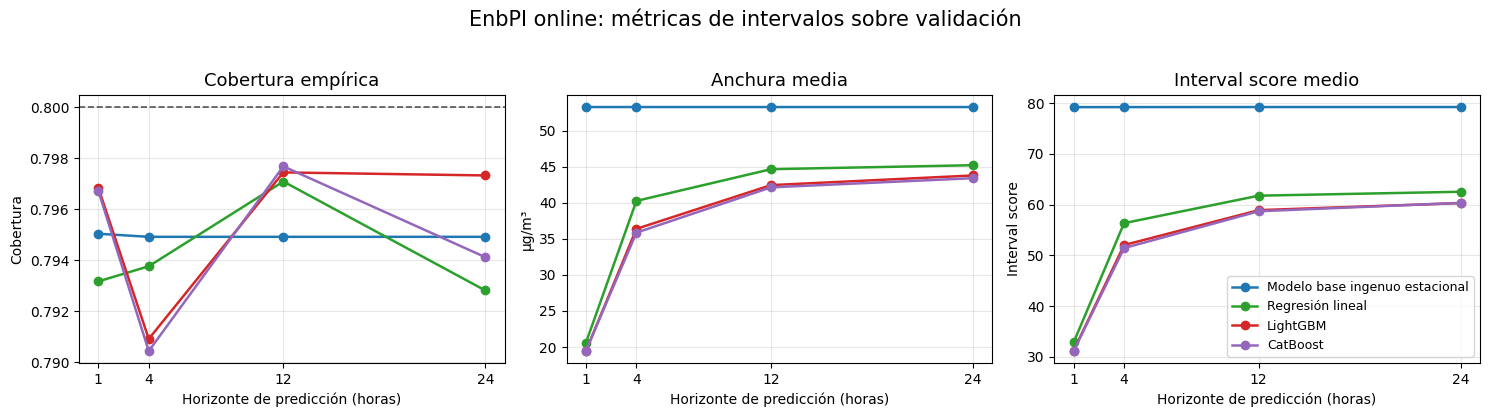

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

metric_specs = [
    ("coverage", "Cobertura empírica", "Cobertura"),
    ("mean_width", "Anchura media", "µg/m³"),
    ("mean_interval_score", "Interval score medio", "Interval score"),
]

for ax, (metric_col, title, ylabel) in zip(axes, metric_specs):
    for model_id in MODEL_ORDER:
        model_df = enbpi_metrics_df.loc[enbpi_metrics_df["model"] == model_id].sort_values("horizon")
        ax.plot(
            model_df["horizon"],
            model_df[metric_col],
            marker="o",
            linewidth=1.8,
            color=MODEL_REGISTRY[model_id]["color"],
            label=MODEL_REGISTRY[model_id]["display_name"],
        )

    if metric_col == "coverage":
        ax.axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1.2, color="black", alpha=0.65)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Horizonte de predicción (horas)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(HORIZONS)
    ax.grid(True, alpha=0.3)

axes[-1].legend(loc="best", fontsize=9)
fig.suptitle("EnbPI online: métricas de intervalos sobre validación", fontsize=15, y=1.03)
fig.tight_layout()

figure_path = REPORTS_FIGURES_DIR / "fig_enbpi_online_metrics_validation.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada: {figure_path}")
plt.show()


Mejor EnbPI en h=24 h: LightGBM
Figura guardada: c:\trabajo_github\reports\figures\fig_enbpi_online_example_best_h24.png


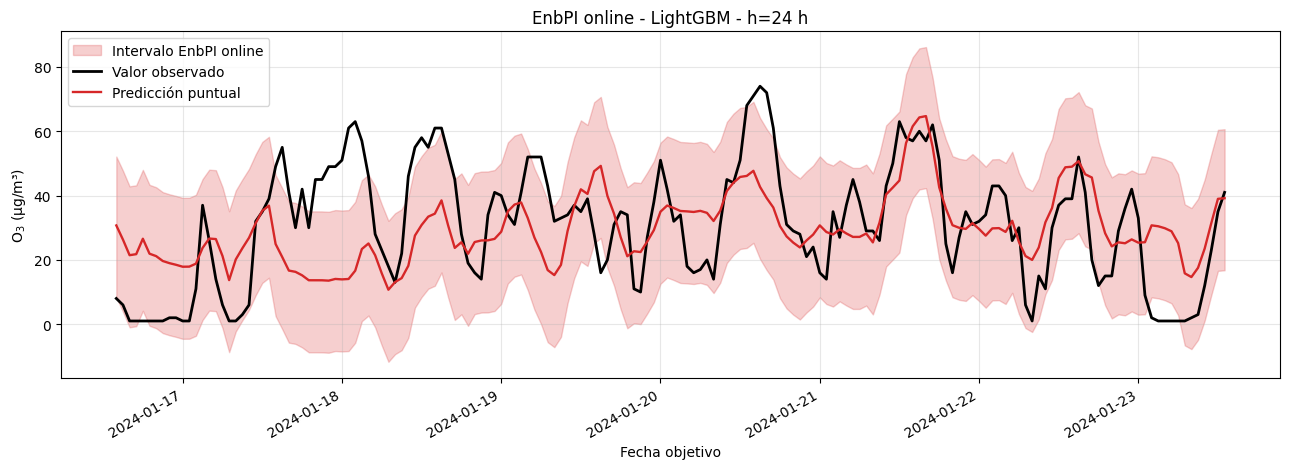

In [11]:
# Figura opcional: ejemplo visual del mejor método EnbPI en h=24.
EXAMPLE_HORIZON = 24
EXAMPLE_HOURS = 7 * 24

best_example_row = (
    enbpi_metrics_df.loc[enbpi_metrics_df["horizon"] == EXAMPLE_HORIZON]
    .sort_values(["mean_interval_score", "coverage_abs_error", "mean_width"], ascending=[True, True, True])
    .iloc[0]
)

best_model_id = best_example_row["model"]
print(f"Mejor EnbPI en h={EXAMPLE_HORIZON} h: {MODEL_REGISTRY[best_model_id]['display_name']}")

example_df = all_enbpi_intervals.loc[
    (all_enbpi_intervals["model"] == best_model_id)
    & (all_enbpi_intervals["horizon"] == EXAMPLE_HORIZON)
].copy()
example_df = example_df.sort_values("target_timestamp").reset_index(drop=True)


def select_continuous_block(df: pd.DataFrame, n_hours: int) -> pd.DataFrame:
    df = df.sort_values("target_timestamp").reset_index(drop=True)
    timestamps = pd.DatetimeIndex(df["target_timestamp"])
    available = set(timestamps)

    for start_ts in timestamps:
        expected = pd.date_range(start=start_ts, periods=n_hours, freq="h")
        if all(ts in available for ts in expected):
            return df.loc[df["target_timestamp"].isin(expected)].copy().sort_values("target_timestamp")

    return df.head(n_hours).copy()


example_block = select_continuous_block(example_df, EXAMPLE_HOURS)

fig, ax = plt.subplots(figsize=(13, 4.8))

ax.fill_between(
    example_block["target_timestamp"],
    example_block["lower"],
    example_block["upper"],
    color=MODEL_REGISTRY[best_model_id]["color"],
    alpha=0.22,
    label="Intervalo EnbPI online",
)
ax.plot(
    example_block["target_timestamp"],
    example_block["y_true"],
    color="black",
    linewidth=2.0,
    label="Valor observado",
)
ax.plot(
    example_block["target_timestamp"],
    example_block["y_pred_reference"],
    color=MODEL_REGISTRY[best_model_id]["color"],
    linewidth=1.7,
    label="Predicción puntual",
)

ax.set_title(f"EnbPI online - {MODEL_REGISTRY[best_model_id]['display_name']} - h={EXAMPLE_HORIZON} h")
ax.set_xlabel("Fecha objetivo")
ax.set_ylabel(r"$\mathrm{O}_3$ (µg/m³)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.autofmt_xdate(rotation=30)
fig.tight_layout()

zoom_path = REPORTS_FIGURES_DIR / f"fig_enbpi_online_example_best_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(zoom_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada: {zoom_path}")
plt.show()


## 7. Comprobaciones finales

In [12]:
expected_interval_files = [
    REPORTS_INTERVALS_DIR / f"{MODEL_REGISTRY[model_id]['interval_prefix']}_h{horizon:02d}.parquet"
    for model_id in MODEL_ORDER
    for horizon in HORIZONS
]

expected_table_files = [
    intervals_all_path,
    metrics_path,
    metrics_wide_path,
    fit_summary_path,
    saved_paths_path,
]

expected_figure_files = [
    figure_path,
    zoom_path,
]

missing_files = [
    path for path in expected_interval_files + expected_table_files + expected_figure_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(f"Faltan archivos esperados: {missing_files}")

if (all_enbpi_intervals["split"] == "test").any():
    raise AssertionError("Se han generado intervalos sobre test, lo que no corresponde en esta fase.")

if all_enbpi_intervals[["lower", "upper", "y_pred_reference"]].isna().any().any():
    raise AssertionError("Existen valores ausentes en predicciones o límites de intervalos.")

if not (all_enbpi_intervals["lower"] <= all_enbpi_intervals["upper"]).all():
    raise AssertionError("Existen intervalos con límite inferior mayor que el superior.")

if len(enbpi_metrics_df) != len(MODEL_ORDER) * len(HORIZONS):
    raise AssertionError("Faltan combinaciones modelo-horizonte en las métricas EnbPI.")

final_check_df = pd.DataFrame(
    {
        "check": [
            "intervalos_guardados",
            "tablas_guardadas",
            "figuras_guardadas",
            "sin_intervalos_test",
            "sin_nan_en_intervalos",
            "limites_coherentes",
            "modelos_y_horizontes_completos",
        ],
        "status": [
            all(path.exists() for path in expected_interval_files),
            all(path.exists() for path in expected_table_files),
            all(path.exists() for path in expected_figure_files),
            not (all_enbpi_intervals["split"] == "test").any(),
            not all_enbpi_intervals[["lower", "upper", "y_pred_reference"]].isna().any().any(),
            bool((all_enbpi_intervals["lower"] <= all_enbpi_intervals["upper"]).all()),
            len(enbpi_metrics_df) == len(MODEL_ORDER) * len(HORIZONS),
        ],
    }
)

display(final_check_df)
print("Comprobaciones finales superadas correctamente.")
print("- Se han generado intervalos EnbPI online para todos los modelos y horizontes.")
print("- La actualización online respeta el desfase origin_timestamp -> target_timestamp.")
print("- Se han guardado tablas, intervalos y figuras de resumen.")


,check,status
0,intervalos_guardados,True
1,tablas_guardadas,True
2,figuras_guardadas,True
3,sin_intervalos_test,True
4,sin_nan_en_intervalos,True
5,limites_coherentes,True
6,modelos_y_horizontes_completos,True


Comprobaciones finales superadas correctamente.
- Se han generado intervalos EnbPI online para todos los modelos y horizontes.
- La actualización online respeta el desfase origin_timestamp -> target_timestamp.
- Se han guardado tablas, intervalos y figuras de resumen.


## 8. Integración posterior con el notebook 07

Este notebook guarda archivos con el patrón:

```text
reports/intervals/enbpi_online_<modelo>_hXX.parquet
```

Para compararlos directamente con `split conformal` y CQR en `07_interval_comparison_and_selection.ipynb`, conviene ampliar el registro de métodos de ese notebook para cargar también estos ficheros y agrupar por `method` además de por `model`, ya que un mismo modelo puede aparecer con CQR y con EnbPI online.
